In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [141]:
berkshireUnem = pd.read_csv("UnemployBerkshire.csv")
franklinUnem = pd.read_csv("UnemployFranklin.csv")
hampdenUnem = pd.read_csv("UnemployHampden.csv")
hampshireUnem = pd.read_csv("UnemployHampshire.csv")

In [142]:
berkshireUnem = berkshireUnem.rename(columns={"observation_date": "date", "MABERK2URN": "unemployment_rate"})
franklinUnem = franklinUnem.rename(columns={"observation_date": "date", "MAFRAN1URN": "unemployment_rate"})
hampdenUnem = hampdenUnem.rename(columns={"observation_date": "date", "MAHAMP0URN": "unemployment_rate"})
hampshireUnem = hampshireUnem.rename(columns={"observation_date": "date", "MAHAMP5URN": "unemployment_rate"})

In [143]:
berkshireUnem.columns

Index(['date', 'unemployment_rate'], dtype='object')

In [144]:
for df in [berkshireUnem, franklinUnem, hampdenUnem, hampshireUnem]:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month

In [145]:
berkshireUnem['region'] = 'Berkshire'
franklinUnem['region'] = 'Franklin'
hampdenUnem['region'] = 'Hampden'
hampshireUnem['region'] = 'Hampshire'

In [146]:
unemployment_combined = pd.concat([berkshireUnem, franklinUnem, hampdenUnem, hampshireUnem])

In [147]:
unemployment_combined.head()

,date,unemployment_rate,year,month,region
0,1990-01-01,6.8,1990,1,Berkshire
1,1990-02-01,6.8,1990,2,Berkshire
2,1990-03-01,7.0,1990,3,Berkshire
3,1990-04-01,6.8,1990,4,Berkshire
4,1990-05-01,6.5,1990,5,Berkshire


In [148]:
unemployment_combined.tail()

,date,unemployment_rate,year,month,region
431,2025-12-01,4.5,2025,12,Hampshire
432,2026-01-01,4.9,2026,1,Hampshire
433,2026-02-01,4.8,2026,2,Hampshire
434,2026-03-01,4.1,2026,3,Hampshire
435,2026-04-01,3.8,2026,4,Hampshire


In [149]:
holyspringUnem = pd.read_csv("UnemployHolySpring.csv", skiprows=6, skipfooter=4, engine='python')

In [150]:
holyspringUnem = holyspringUnem[holyspringUnem['Month'] != 'Annual']

In [151]:
holyspringUnem['month'] = pd.to_datetime(holyspringUnem['Month'], format='%B').dt.month

In [152]:
holyspringUnem = holyspringUnem.rename(columns={'Area': 'region', 'Year': 'year', 'Unemployment Rate': 'unemployment_rate', 'Area Rate': 'unemployment_rate'})

In [153]:
holyspringUnem['year'] = holyspringUnem['year'].astype(int)

In [154]:
unemployment_combined = pd.concat([unemployment_combined, holyspringUnem])

In [155]:
unemployment_combined.head()

,date,unemployment_rate,year,month,region,Month,Labor Force,Employed,Unemployed,Massachusetts Rate
0,1990-01-01,6.8,1990,1,Berkshire,NaN,NaN,NaN,NaN,NaN
1,1990-02-01,6.8,1990,2,Berkshire,NaN,NaN,NaN,NaN,NaN
2,1990-03-01,7.0,1990,3,Berkshire,NaN,NaN,NaN,NaN,NaN
3,1990-04-01,6.8,1990,4,Berkshire,NaN,NaN,NaN,NaN,NaN
4,1990-05-01,6.5,1990,5,Berkshire,NaN,NaN,NaN,NaN,NaN


In [156]:
unemployment_combined.tail()

,date,unemployment_rate,year,month,region,Month,Labor Force,Employed,Unemployed,Massachusetts Rate
936,NaT,8.5,1990,8,Springfield,August,70925.0,64931.0,5994.0,6.5
937,NaT,8.5,1990,9,Springfield,September,69904.0,63972.0,5932.0,6.8
938,NaT,8.1,1990,10,Springfield,October,69846.0,64160.0,5686.0,6.6
939,NaT,9.1,1990,11,Springfield,November,70143.0,63783.0,6360.0,7.1
940,NaT,9.7,1990,12,Springfield,December,69939.0,63174.0,6765.0,7.5


In [157]:
weatherBerkshire = pd.read_csv("WeathBerkshire.csv", skiprows=3, engine='python', encoding='utf-8')
weatherFranklin = pd.read_csv("WeathFranklin.csv", skiprows=3, engine='python', encoding='utf-8')
weatherHampden = pd.read_csv("WeathHampdenHolySpring.csv", skiprows=3, engine='python', encoding='utf-8')
weatherHampshire = pd.read_csv("WeathHampshire.csv", skiprows=3, engine='python', encoding='utf-8')

In [158]:
for df in [weatherBerkshire, weatherFranklin, weatherHampden, weatherHampshire]:
    df['time'] = pd.to_datetime(df['time'])
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month

In [159]:
weatherBerkshire = weatherBerkshire.rename(columns={"temperature_2m_mean (°C)": "mean_temperature", "temperature_2m_min (°C)": "min_temperature", "precipitation_sum (mm)": "precipitation(mm)"})
weatherFranklin = weatherFranklin.rename(columns={"temperature_2m_mean (°C)": "mean_temperature", "temperature_2m_min (°C)": "min_temperature", "precipitation_sum (mm)": "precipitation(mm)"})
weatherHampden = weatherHampden.rename(columns={"temperature_2m_mean (°C)": "mean_temperature", "temperature_2m_min (°C)": "min_temperature", "precipitation_sum (mm)": "precipitation(mm)"})
weatherHampshire = weatherHampshire.rename(columns={"temperature_2m_mean (°C)": "mean_temperature", "temperature_2m_min (°C)": "min_temperature", "precipitation_sum (mm)": "precipitation(mm)"})

In [160]:
def aggregate_to_monthly(df):
    return df.groupby(['year', 'month']).agg({
        'mean_temperature': 'mean',
        'min_temperature': 'mean',
        'precipitation(mm)': 'sum'
    }).reset_index()

weatherBerkshire = aggregate_to_monthly(weatherBerkshire)
weatherFranklin = aggregate_to_monthly(weatherFranklin)
weatherHampden = aggregate_to_monthly(weatherHampden)
weatherHampshire = aggregate_to_monthly(weatherHampshire)

In [161]:
weatherBerkshire['region'] = 'Berkshire'
weatherFranklin['region'] = 'Franklin'
weatherHampden['region'] = 'Hampden'
weatherHampshire['region'] = 'Hampshire'

In [162]:
weatherHolyoke = weatherHampden.copy()
weatherHolyoke['region'] = 'Holyoke'
weatherSpringfield = weatherHampden.copy()
weatherSpringfield['region'] = 'Springfield'

In [163]:
combined_weather = pd.concat([weatherBerkshire, weatherFranklin, weatherHampden, weatherHampshire, weatherHolyoke, weatherSpringfield])

In [164]:
combined_weather.head()

,year,month,mean_temperature,min_temperature,precipitation(mm),region
0,1990,1,-0.541935,-4.493548,115.1,Berkshire
1,1990,2,-1.914286,-7.585714,107.8,Berkshire
2,1990,3,2.658065,-2.158065,93.2,Berkshire
3,1990,4,7.850000,3.376667,112.3,Berkshire
4,1990,5,11.548387,7.129032,201.3,Berkshire


In [165]:
combined_weather.tail()

,year,month,mean_temperature,min_temperature,precipitation(mm),region
431,2025,12,-2.512903,-6.690323,98.7,Springfield
432,2026,1,-4.932258,-9.116129,77.9,Springfield
433,2026,2,-4.914286,-10.039286,47.7,Springfield
434,2026,3,4.083871,-1.109677,154.1,Springfield
435,2026,4,15.400000,8.800000,4.7,Springfield


In [166]:
print(combined_weather['region'].unique())

['Berkshire' 'Franklin' 'Hampden' 'Hampshire' 'Holyoke' 'Springfield']


In [167]:
final_data = pd.merge(unemployment_combined, combined_weather, on=['year', 'month', 'region'])

In [168]:
print(final_data.shape)
final_data.head()


(2614, 13)


,date,unemployment_rate,year,month,region,Month,Labor Force,Employed,Unemployed,Massachusetts Rate,mean_temperature,min_temperature,precipitation(mm)
0,1990-01-01,6.8,1990,1,Berkshire,NaN,NaN,NaN,NaN,NaN,-0.541935,-4.493548,115.1
1,1990-02-01,6.8,1990,2,Berkshire,NaN,NaN,NaN,NaN,NaN,-1.914286,-7.585714,107.8
2,1990-03-01,7.0,1990,3,Berkshire,NaN,NaN,NaN,NaN,NaN,2.658065,-2.158065,93.2
3,1990-04-01,6.8,1990,4,Berkshire,NaN,NaN,NaN,NaN,NaN,7.850000,3.376667,112.3
4,1990-05-01,6.5,1990,5,Berkshire,NaN,NaN,NaN,NaN,NaN,11.548387,7.129032,201.3


In [169]:
final_data.tail()

,date,unemployment_rate,year,month,region,Month,Labor Force,Employed,Unemployed,Massachusetts Rate,mean_temperature,min_temperature,precipitation(mm)
2609,NaT,8.5,1990,8,Springfield,August,70925.0,64931.0,5994.0,6.5,21.648387,17.738710,222.3
2610,NaT,8.5,1990,9,Springfield,September,69904.0,63972.0,5932.0,6.8,16.886667,12.683333,44.6
2611,NaT,8.1,1990,10,Springfield,October,69846.0,64160.0,5686.0,6.6,13.577419,9.761290,109.7
2612,NaT,9.1,1990,11,Springfield,November,70143.0,63783.0,6360.0,7.1,6.333333,2.366667,57.5
2613,NaT,9.7,1990,12,Springfield,December,69939.0,63174.0,6765.0,7.5,2.503226,-0.983871,143.0


In [170]:
final_data = final_data[~((final_data['year'] == 2025) & (final_data['month'] == 10))]

In [171]:
final_data = final_data.sort_values(['region', 'year', 'month']).reset_index(drop=True)

In [172]:
final_data['heating_season'] = final_data['month'].isin([11, 12, 1, 2, 3]).astype(int)
final_data['summer_break'] = final_data['month'].isin([6, 7, 8]).astype(int)
final_data = final_data[~((final_data['year'] == 2020))]

In [173]:
final_data.to_csv("final_data.csv", index=False)

In [174]:
df =  pd.read_csv("FoodBankOutputCS.csv", encoding='utf-8-sig')
print(df[(df['region'] == 'Hampden') & (df['year'] == 2020) & (df['month'] == 10)]['meals_provided'].values)

[731792]


In [175]:
springfield = df[df['region'] == 'Springfield'][['year', 'month', 'people_assisted', 'meals_provided']].rename(
    columns={'people_assisted': 'sp_people', 'meals_provided': 'sp_meals'})

holyoke = df[df['region'] == 'Holyoke'][['year', 'month', 'people_assisted', 'meals_provided']].rename(
    columns={'people_assisted': 'hol_people', 'meals_provided': 'hol_meals'})

hampden = df[df['region'] == 'Hampden'].merge(springfield, on=['year', 'month']).merge(holyoke, on=['year', 'month'])
hampden['people_assisted'] = hampden['people_assisted'] - hampden['sp_people'] - hampden['hol_people']
hampden['meals_provided'] = hampden['meals_provided'] - hampden['sp_meals'] - hampden['hol_meals']
hampden = hampden[['year', 'month', 'region', 'people_assisted', 'meals_provided']]

df = pd.concat([df[df['region'] != 'Hampden'], hampden]).sort_values(['region', 'year', 'month']).reset_index(drop=True)

In [176]:
print(df[(df['region'] == 'Hampden') & (df['year'] == 2020) & (df['month'] == 10)]['meals_provided'].values)

[127493]


In [177]:
final_data = pd.merge(final_data, df, on=['region', 'year', 'month'])

In [178]:
print(final_data.shape)
print(final_data.columns.tolist())
final_data.head()

(378, 17)
['date', 'unemployment_rate', 'year', 'month', 'region', 'Month', 'Labor Force', 'Employed', 'Unemployed', 'Massachusetts Rate', 'mean_temperature', 'min_temperature', 'precipitation(mm)', 'heating_season', 'summer_break', 'people_assisted', 'meals_provided']


,date,unemployment_rate,year,month,region,Month,Labor Force,Employed,Unemployed,Massachusetts Rate,mean_temperature,min_temperature,precipitation(mm),heating_season,summer_break,people_assisted,meals_provided
0,2021-01-01,8.5,2021,1,Berkshire,NaN,NaN,NaN,NaN,NaN,-4.525806,-8.335484,57.2,1,0,13605,177563
1,2021-02-01,8.3,2021,2,Berkshire,NaN,NaN,NaN,NaN,NaN,-4.396429,-8.660714,72.2,1,0,13655,162886
2,2021-03-01,7.7,2021,3,Berkshire,NaN,NaN,NaN,NaN,NaN,1.896774,-4.196774,58.9,1,0,15895,184962
3,2021-04-01,6.8,2021,4,Berkshire,NaN,NaN,NaN,NaN,NaN,7.653333,2.020000,134.1,0,0,13783,188075
4,2021-05-01,6.2,2021,5,Berkshire,NaN,NaN,NaN,NaN,NaN,12.864516,7.687097,117.8,0,0,13773,181544


In [179]:
final_data.columns.tolist()

['date',
 'unemployment_rate',
 'year',
 'month',
 'region',
 'Month',
 'Labor Force',
 'Employed',
 'Unemployed',
 'Massachusetts Rate',
 'mean_temperature',
 'min_temperature',
 'precipitation(mm)',
 'heating_season',
 'summer_break',
 'people_assisted',
 'meals_provided']

In [180]:
final_data = final_data.drop(columns=['date', 'Month', 'Labor Force', 'Employed', 'Unemployed', 'Massachusetts Rate'])

In [181]:
final_data = final_data.sort_values(['region', 'year', 'month'])
final_data['prev_month_people'] = final_data.groupby('region')['people_assisted'].shift(1)
final_data = final_data.dropna()

In [182]:
final_data.to_csv("final_data_clean.csv", index=False)

In [183]:
# Encode region
le = LabelEncoder()
final_data['region_encoded'] = le.fit_transform(final_data['region'])

# Features and target
X = final_data[['unemployment_rate', 'year', 'month', 'region_encoded', 
                 'mean_temperature', 'min_temperature', 'precipitation(mm)', 
                 'heating_season', 'summer_break', 'prev_month_people']]
y = final_data['people_assisted']

# Time based split
X_train = X[final_data['year'] < 2024]
X_test = X[final_data['year'] >= 2024]
y_train = y[final_data['year'] < 2024]
y_test = y[final_data['year'] >= 2024]

# Train
model = RandomForestRegressor(n_estimators=100, max_depth=5, min_samples_leaf=3, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, predictions))
print("R²:", r2_score(y_test, predictions))

MAE: 1668.618947361094
R²: 0.8873103242853139


In [184]:
baseline_predictions = np.full(len(y_test), y_train.mean())
print("Baseline MAE:", mean_absolute_error(y_test, baseline_predictions))
print("Baseline R²:", r2_score(y_test, baseline_predictions))

Baseline MAE: 6038.1382716049375
Baseline R²: -0.31135838269662885


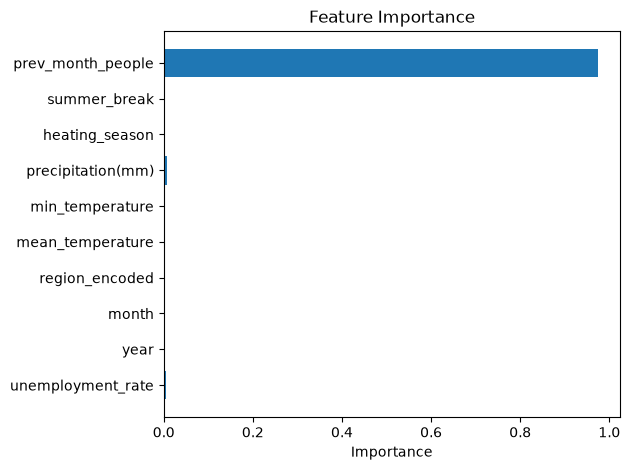

In [185]:
feature_names = X.columns.tolist()
importances = model.feature_importances_

plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

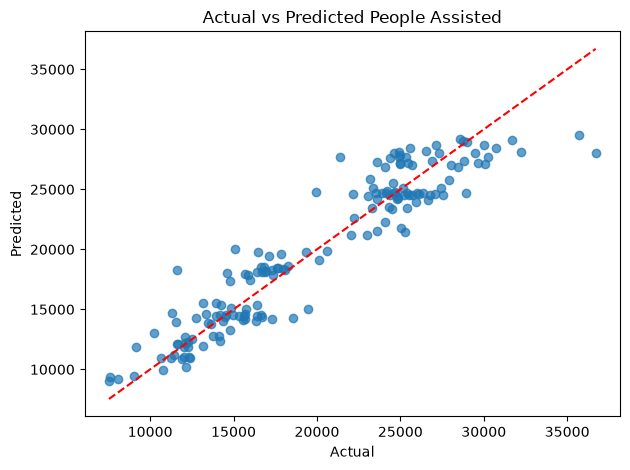

In [186]:
plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted People Assisted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.tight_layout()
plt.show()

In [187]:
joblib.dump(model, 'food_bank_model.pkl')

['food_bank_model.pkl']

In [188]:
# Example: predict for Springfield, February 2025
# prev_month_people would be January 2025's actual number for Springfield
example = pd.DataFrame([{
    'unemployment_rate': 7.3,
    'year': 2025,
    'month': 2,
    'region_encoded': le.transform(['Springfield'])[0],
    'mean_temperature': -1.5,
    'min_temperature': -6.0,
    'precipitation(mm)': 80.0,
    'heating_season': 1,
    'summer_break': 0,
    'prev_month_people': 12000
}])

print("Predicted people assisted:", model.predict(example)[0])

Predicted people assisted: 12213.541418900379
